In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [ ]:
bnb = pd.read_csv("BnbData.csv")
coke = pd.read_csv("COKEData.csv")
exx = pd.read_csv("EXXData.csv")
jp = pd.read_csv("JPData.csv")
mkt = pd.read_csv("MKT Return .csv")
rf = pd.read_csv("DGS3MO.csv")
ff = pd.read_csv("F-F_Research_Data_Factors_daily.csv", skiprows=4)

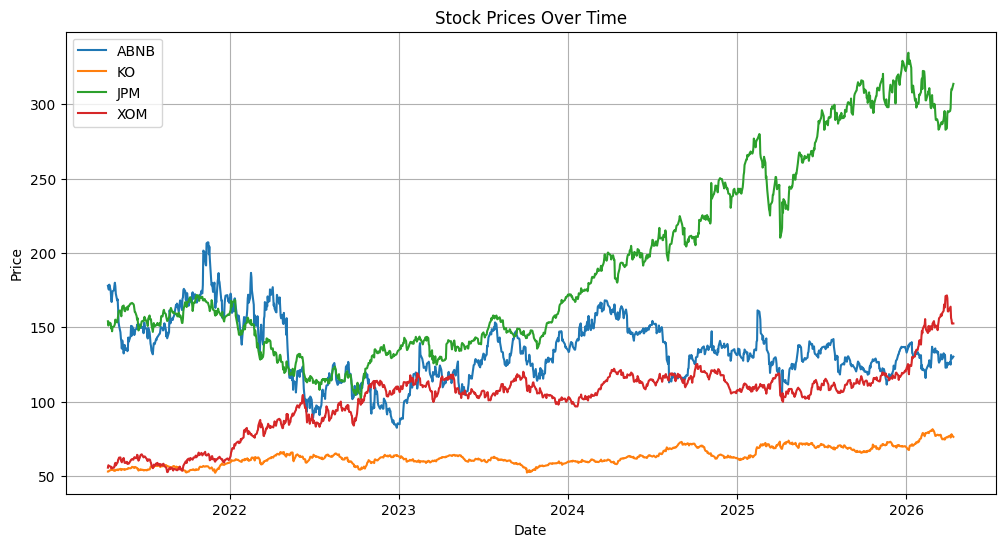

In [ ]:
# PRICE DATA CLEANING FOR PRICE-VS-RETURN CHART

bnb_price = pd.read_csv("BnbData.csv")
coke_price = pd.read_csv("COKEData.csv")
exx_price = pd.read_csv("EXXData.csv")
jp_price = pd.read_csv("JPData.csv")

def clean_price(df, new_name):
    df = df[["Date", "Price"]].copy()
    df.rename(columns={"Price": new_name}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")
    df[new_name] = pd.to_numeric(df[new_name], errors="coerce")
    df = df.sort_values("Date").dropna()
    return df

bnb_price = clean_price(bnb_price, "ABNB_PRICE")
coke_price = clean_price(coke_price, "KO_PRICE")
exx_price = clean_price(exx_price, "XOM_PRICE")
jp_price = clean_price(jp_price, "JPM_PRICE")

price_df = (
    bnb_price.merge(coke_price, on="Date", how="inner")
             .merge(exx_price, on="Date", how="inner")
             .merge(jp_price, on="Date", how="inner")
)

plt.figure()
plt.plot(price_df["Date"], price_df["ABNB_PRICE"], label="ABNB")
plt.plot(price_df["Date"], price_df["KO_PRICE"], label="KO")
plt.plot(price_df["Date"], price_df["JPM_PRICE"], label="JPM")
plt.plot(price_df["Date"], price_df["XOM_PRICE"], label="XOM")
plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
def clean_stock(df, ret_col, new_name):
    df = df[["Date", ret_col]].copy()
    df.rename(columns={ret_col: new_name}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")
    df[new_name] = pd.to_numeric(df[new_name], errors="coerce") / 100
    df = df.sort_values("Date").dropna()
    return df

bnb = clean_stock(bnb, "% Return", "ABNB_RET")
coke = clean_stock(coke, "% Return", "KO_RET")
exx = clean_stock(exx, "% Return", "XOM_RET")
jp = clean_stock(jp, "% Return", "JPM_RET")

In [ ]:
mkt = mkt[["Date", "% Change"]].copy()
mkt.rename(columns={"% Change": "MKT_RET"}, inplace=True)
mkt["Date"] = pd.to_datetime(mkt["Date"], format="%m/%d/%y")
mkt["MKT_RET"] = pd.to_numeric(mkt["MKT_RET"], errors="coerce") / 100
mkt = mkt.sort_values("Date").dropna()

In [ ]:
rf = rf[["observation_date", "DGS3MO"]].copy()
rf.rename(columns={"observation_date": "Date", "DGS3MO": "RF"}, inplace=True)

rf["Date"] = pd.to_datetime(rf["Date"])
rf["RF"] = pd.to_numeric(rf["RF"], errors="coerce")

rf = rf.dropna().sort_values("Date")

# Convert annual percent yield to daily decimal rate
rf["RF"] = rf["RF"] / 100 / 252

In [ ]:
ff.columns = ["Date", "MKT_RF", "SMB", "HML", "RF_FF"]

# Keep only rows where Date is numeric like 20210412
ff["Date"] = ff["Date"].astype(str)
ff = ff[ff["Date"].str.isnumeric()].copy()

# Convert date
ff["Date"] = pd.to_datetime(ff["Date"], format="%Y%m%d")

# Convert factors from percent to decimal
for col in ["MKT_RF", "SMB", "HML", "RF_FF"]:
    ff[col] = pd.to_numeric(ff[col], errors="coerce") / 100

ff = ff[["Date", "MKT_RF", "SMB", "HML"]].dropna().sort_values("Date")

In [ ]:
df = (
    bnb.merge(coke, on="Date", how="inner")
       .merge(exx, on="Date", how="inner")
       .merge(jp, on="Date", how="inner")
       .merge(mkt, on="Date", how="inner")
       .merge(rf, on="Date", how="inner")
       .merge(ff, on="Date", how="inner")
)

df = df.sort_values("Date").dropna().reset_index(drop=True)

print(df.head())
print(df.shape)

        Date  ABNB_RET  KO_RET  XOM_RET  JPM_RET  MKT_RET            RF  \
0 2021-04-14   -0.0085 -0.0002   0.0289  -0.0187  -0.0041  7.936508e-07   
1 2021-04-15   -0.0061  0.0047  -0.0059   0.0063   0.0111  7.936508e-07   
2 2021-04-16    0.0190  0.0066  -0.0056   0.0074   0.0036  7.936508e-07   
3 2021-04-19   -0.0230  0.0060  -0.0032  -0.0042  -0.0053  7.936508e-07   
4 2021-04-20   -0.0287  0.0031  -0.0211  -0.0221  -0.0068  1.190476e-06   

   MKT_RF     SMB     HML  
0 -0.0034  0.0079  0.0141  
1  0.0106 -0.0044 -0.0119  
2  0.0027 -0.0036  0.0065  
3 -0.0072 -0.0078  0.0079  
4 -0.0093 -0.0118 -0.0157  
(1199, 10)


In [ ]:
df["EW_PORT"] = (
    0.25 * df["ABNB_RET"] +
    0.25 * df["KO_RET"] +
    0.25 * df["JPM_RET"] +
    0.25 * df["XOM_RET"]
)

In [ ]:
df["ABNB_EXCESS"] = df["ABNB_RET"] - df["RF"]
df["KO_EXCESS"] = df["KO_RET"] - df["RF"]
df["JPM_EXCESS"] = df["JPM_RET"] - df["RF"]
df["XOM_EXCESS"] = df["XOM_RET"] - df["RF"]

df["EW_PORT_EXCESS"] = df["EW_PORT"] - df["RF"]
df["MKT_EXCESS"] = df["MKT_RET"] - df["RF"]

In [ ]:
print(df[[
    "Date", "ABNB_RET", "KO_RET", "JPM_RET", "XOM_RET",
    "EW_PORT", "MKT_RET", "RF", "MKT_RF", "SMB", "HML"
]].head())

        Date  ABNB_RET  KO_RET  JPM_RET  XOM_RET   EW_PORT  MKT_RET  \
0 2021-04-14   -0.0085 -0.0002  -0.0187   0.0289  0.000375  -0.0041   
1 2021-04-15   -0.0061  0.0047   0.0063  -0.0059 -0.000250   0.0111   
2 2021-04-16    0.0190  0.0066   0.0074  -0.0056  0.006850   0.0036   
3 2021-04-19   -0.0230  0.0060  -0.0042  -0.0032 -0.006100  -0.0053   
4 2021-04-20   -0.0287  0.0031  -0.0221  -0.0211 -0.017200  -0.0068   

             RF  MKT_RF     SMB     HML  
0  7.936508e-07 -0.0034  0.0079  0.0141  
1  7.936508e-07  0.0106 -0.0044 -0.0119  
2  7.936508e-07  0.0027 -0.0036  0.0065  
3  7.936508e-07 -0.0072 -0.0078  0.0079  
4  1.190476e-06 -0.0093 -0.0118 -0.0157  


In [ ]:
summary_stats = df[["ABNB_RET", "KO_RET", "JPM_RET", "XOM_RET", "EW_PORT"]].describe().T
summary_stats["skew"] = df[["ABNB_RET", "KO_RET", "JPM_RET", "XOM_RET", "EW_PORT"]].skew()
summary_stats["kurtosis"] = df[["ABNB_RET", "KO_RET", "JPM_RET", "XOM_RET", "EW_PORT"]].kurt()

print(summary_stats)

           count      mean       std       min       25%       50%       75%  \
ABNB_RET  1199.0 -0.000008  0.027841 -0.134300 -0.014700  0.000300  0.014450   
KO_RET    1199.0  0.000526  0.010028 -0.069600 -0.005200  0.000700  0.006100   
JPM_RET   1199.0  0.000754  0.015493 -0.074400 -0.007400  0.001200  0.009200   
XOM_RET   1199.0  0.001157  0.016725 -0.078900 -0.008750  0.001400  0.011500   
EW_PORT   1199.0  0.000607  0.011882 -0.063725 -0.006087  0.000725  0.007112   

             max      skew  kurtosis  
ABNB_RET  0.1479  0.016688  3.232208  
KO_RET    0.0473 -0.246147  3.757763  
JPM_RET   0.1154  0.098604  5.094651  
XOM_RET   0.0641 -0.215719  1.359454  
EW_PORT   0.0752 -0.103803  3.082851  


In [ ]:
annual_stats = pd.DataFrame({
    "Annualized Return": df[["ABNB_RET", "KO_RET", "JPM_RET", "XOM_RET", "EW_PORT"]].mean() * 252,
    "Annualized Volatility": df[["ABNB_RET", "KO_RET", "JPM_RET", "XOM_RET", "EW_PORT"]].std() * np.sqrt(252)
})

print(annual_stats)

          Annualized Return  Annualized Volatility
ABNB_RET          -0.002102               0.441965
KO_RET             0.132599               0.159191
JPM_RET            0.189893               0.245937
XOM_RET            0.291618               0.265495
EW_PORT            0.153002               0.188617


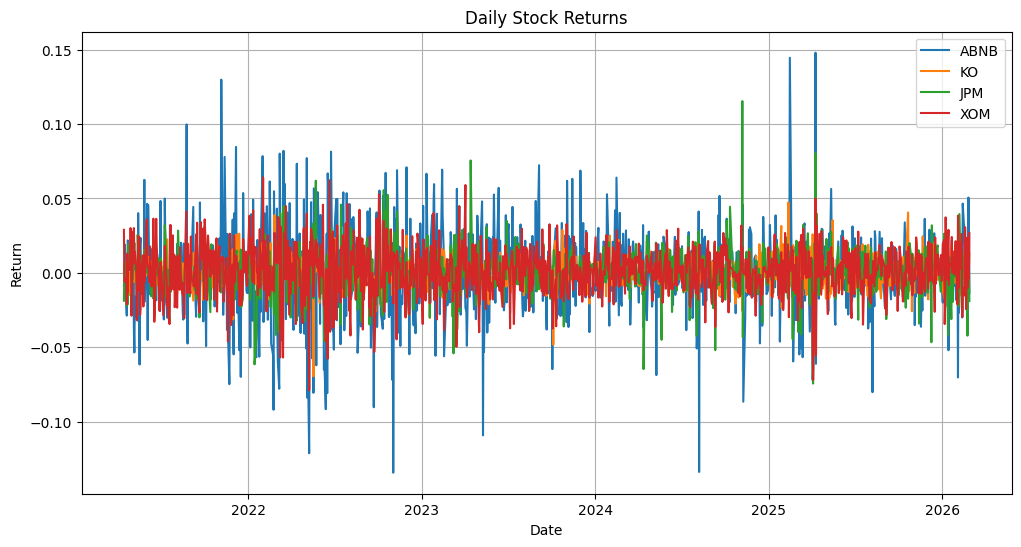

In [ ]:
plt.figure()
plt.plot(df["Date"], df["ABNB_RET"], label="ABNB")
plt.plot(df["Date"], df["KO_RET"], label="KO")
plt.plot(df["Date"], df["JPM_RET"], label="JPM")
plt.plot(df["Date"], df["XOM_RET"], label="XOM")
plt.title("Daily Stock Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

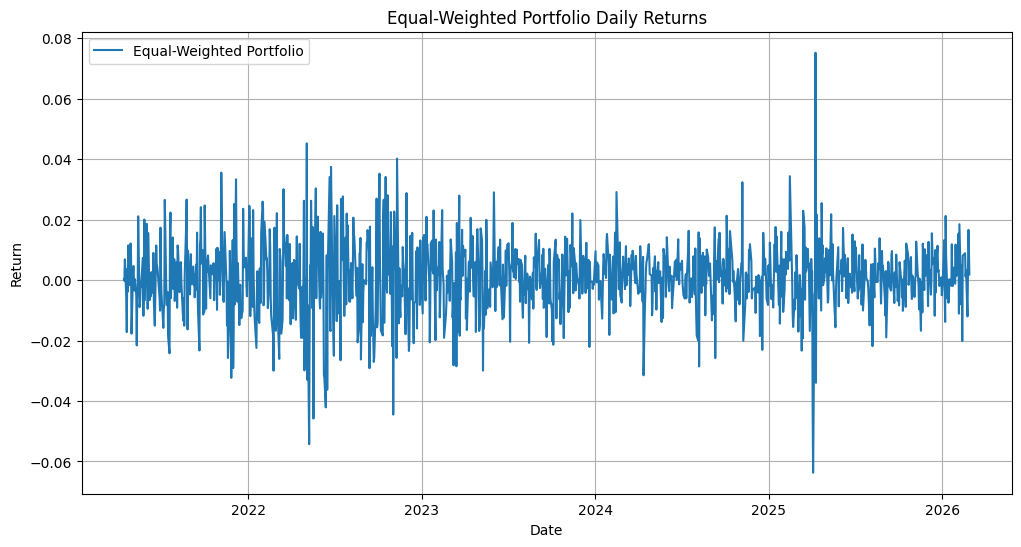

In [ ]:
plt.figure()
plt.plot(df["Date"], df["EW_PORT"], label="Equal-Weighted Portfolio")
plt.title("Equal-Weighted Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

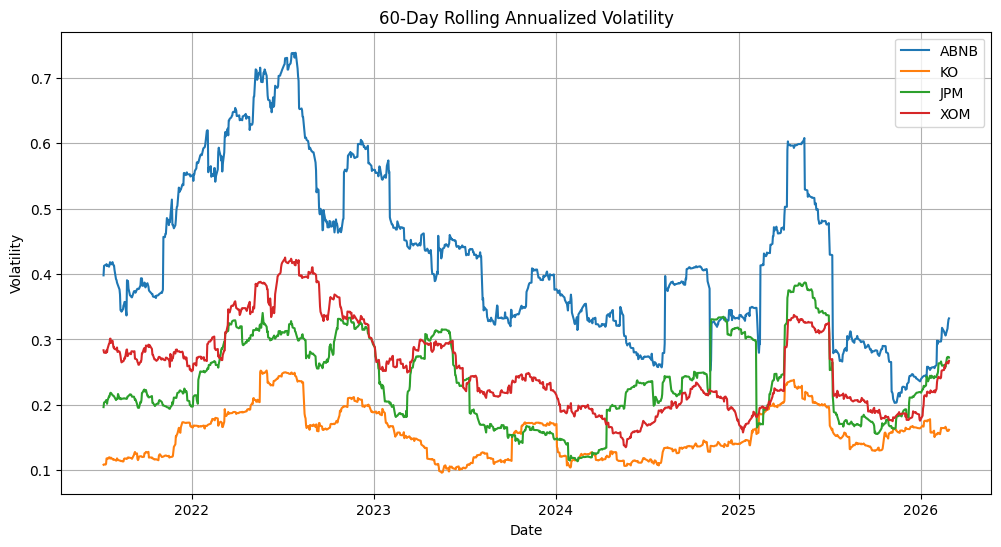

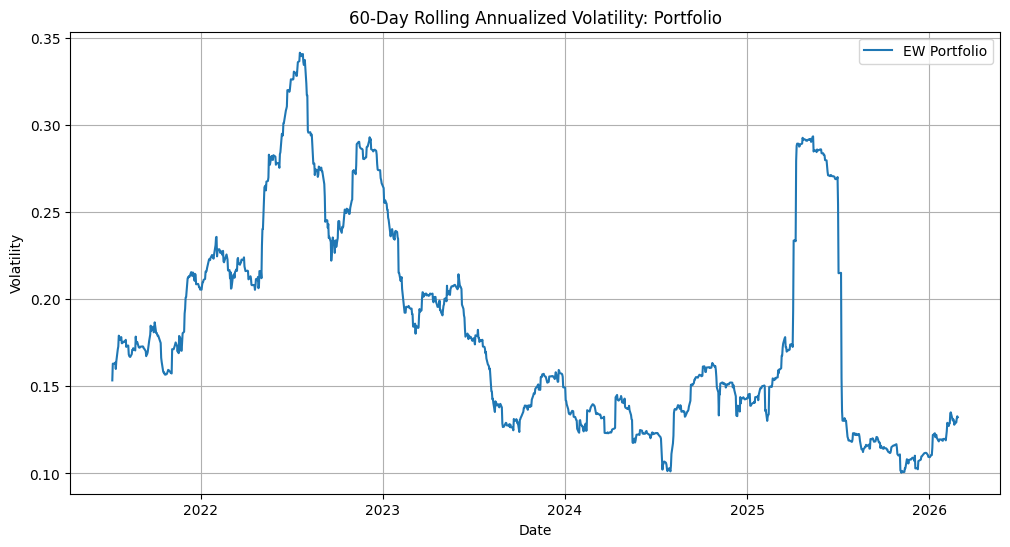

In [ ]:
rolling_window = 60

rolling_vol = pd.DataFrame()
rolling_vol["Date"] = df["Date"]
rolling_vol["ABNB_VOL"] = df["ABNB_RET"].rolling(rolling_window).std() * np.sqrt(252)
rolling_vol["KO_VOL"] = df["KO_RET"].rolling(rolling_window).std() * np.sqrt(252)
rolling_vol["JPM_VOL"] = df["JPM_RET"].rolling(rolling_window).std() * np.sqrt(252)
rolling_vol["XOM_VOL"] = df["XOM_RET"].rolling(rolling_window).std() * np.sqrt(252)
rolling_vol["PORT_VOL"] = df["EW_PORT"].rolling(rolling_window).std() * np.sqrt(252)

plt.figure()
plt.plot(rolling_vol["Date"], rolling_vol["ABNB_VOL"], label="ABNB")
plt.plot(rolling_vol["Date"], rolling_vol["KO_VOL"], label="KO")
plt.plot(rolling_vol["Date"], rolling_vol["JPM_VOL"], label="JPM")
plt.plot(rolling_vol["Date"], rolling_vol["XOM_VOL"], label="XOM")
plt.title("60-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

plt.figure()
plt.plot(rolling_vol["Date"], rolling_vol["PORT_VOL"], label="EW Portfolio")
plt.title("60-Day Rolling Annualized Volatility: Portfolio")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

          ABNB_RET    KO_RET   JPM_RET   XOM_RET
ABNB_RET  1.000000  0.086860  0.369171  0.204361
KO_RET    0.086860  1.000000  0.225161  0.175949
JPM_RET   0.369171  0.225161  1.000000  0.341790
XOM_RET   0.204361  0.175949  0.341790  1.000000


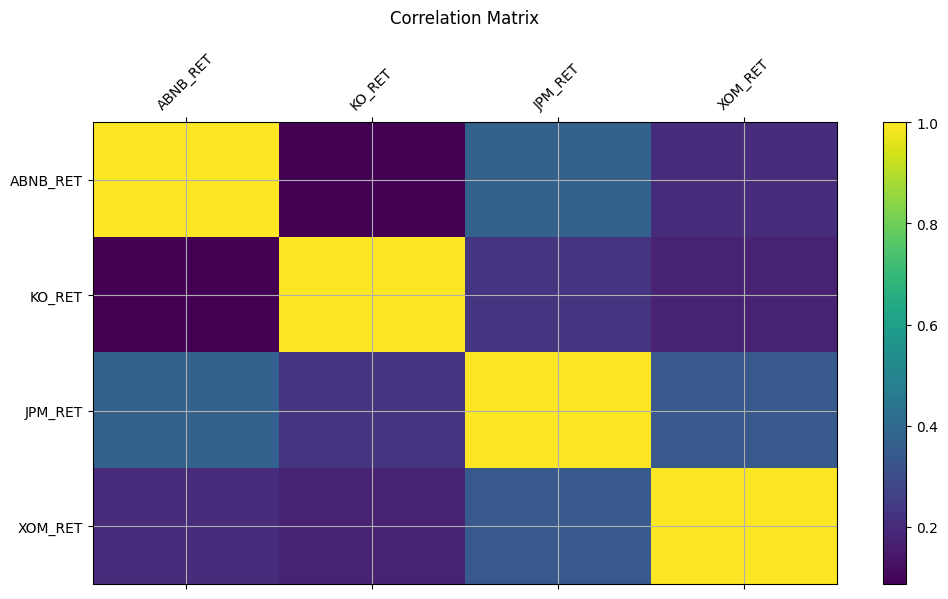

In [ ]:
corr_matrix = df[["ABNB_RET", "KO_RET", "JPM_RET", "XOM_RET"]].corr()
print(corr_matrix)

fig, ax = plt.subplots()
cax = ax.matshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.colorbar(cax)
plt.title("Correlation Matrix", pad=20)
plt.show()

In [ ]:
var_95 = df["EW_PORT"].quantile(0.05)
cvar_95 = df.loc[df["EW_PORT"] <= var_95, "EW_PORT"].mean()

print(f"95% Daily VaR: {var_95:.4%}")
print(f"95% Daily CVaR: {cvar_95:.4%}")

95% Daily VaR: -1.8625%
95% Daily CVaR: -2.6930%


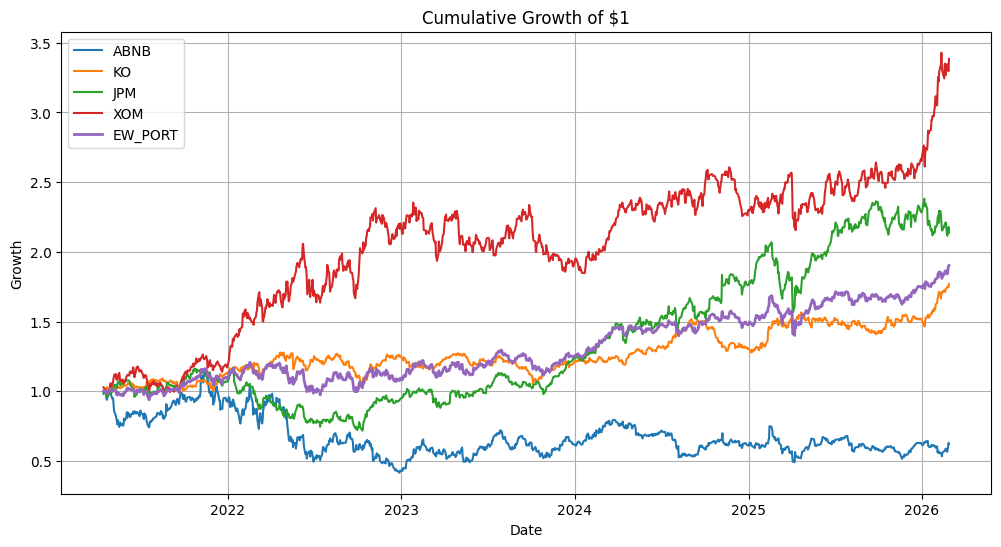

In [ ]:
cum = pd.DataFrame()
cum["Date"] = df["Date"]
cum["ABNB"] = (1 + df["ABNB_RET"]).cumprod()
cum["KO"] = (1 + df["KO_RET"]).cumprod()
cum["JPM"] = (1 + df["JPM_RET"]).cumprod()
cum["XOM"] = (1 + df["XOM_RET"]).cumprod()
cum["EW_PORT"] = (1 + df["EW_PORT"]).cumprod()

plt.figure()
plt.plot(cum["Date"], cum["ABNB"], label="ABNB")
plt.plot(cum["Date"], cum["KO"], label="KO")
plt.plot(cum["Date"], cum["JPM"], label="JPM")
plt.plot(cum["Date"], cum["XOM"], label="XOM")
plt.plot(cum["Date"], cum["EW_PORT"], label="EW_PORT", linewidth=2)
plt.title("Cumulative Growth of $1")
plt.xlabel("Date")
plt.ylabel("Growth")
plt.legend()
plt.show()

In [ ]:
X_capm = sm.add_constant(df["MKT_EXCESS"])
y_port = df["EW_PORT_EXCESS"]

capm_port = sm.OLS(y_port, X_capm).fit()
print(capm_port.summary())

                            OLS Regression Results                            
Dep. Variable:         EW_PORT_EXCESS   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     1480.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.83e-211
Time:                        22:00:09   Log-Likelihood:                 4096.7
No. Observations:                1199   AIC:                            -8189.
Df Residuals:                    1197   BIC:                            -8179.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.933      0.3

In [ ]:
# OPTIONAL CLEANER CAPM USING THE SAME MARKET FACTOR SOURCE AS FF3

X_capm_ff = sm.add_constant(df["MKT_RF"])
y_port = df["EW_PORT_EXCESS"]

capm_port_ff = sm.OLS(y_port, X_capm_ff).fit()
print(capm_port_ff.summary())

                            OLS Regression Results                            
Dep. Variable:         EW_PORT_EXCESS   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     1564.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.81e-219
Time:                        22:00:09   Log-Likelihood:                 4115.2
No. Observations:                1199   AIC:                            -8226.
Df Residuals:                    1197   BIC:                            -8216.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.918      0.3

In [ ]:
stocks = ["ABNB", "KO", "JPM", "XOM"]

for stock in stocks:
    print(f"\n===== CAPM RESULTS: {stock} =====")
    y = df[f"{stock}_EXCESS"]
    X = sm.add_constant(df["MKT_EXCESS"])
    model = sm.OLS(y, X).fit()
    print(model.summary())


===== CAPM RESULTS: ABNB =====
                            OLS Regression Results                            
Dep. Variable:            ABNB_EXCESS   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     670.8
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          8.49e-118
Time:                        22:00:09   Log-Likelihood:                 2859.9
No. Observations:                1199   AIC:                            -5716.
Df Residuals:                    1197   BIC:                            -5706.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.000

In [ ]:
X_ff = sm.add_constant(df[["MKT_RF", "SMB", "HML"]])
y_port = df["EW_PORT_EXCESS"]

ff3_port = sm.OLS(y_port, X_ff).fit()
print(ff3_port.summary())

                            OLS Regression Results                            
Dep. Variable:         EW_PORT_EXCESS   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     767.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          5.44e-278
Time:                        22:00:09   Log-Likelihood:                 4257.8
No. Observations:                1199   AIC:                            -8508.
Df Residuals:                    1195   BIC:                            -8487.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.321e-05      0.000      0.314      0.7

In [ ]:
for stock in stocks:
    print(f"\n===== FF3 RESULTS: {stock} =====")
    y = df[f"{stock}_EXCESS"]
    X = sm.add_constant(df[["MKT_RF", "SMB", "HML"]])
    model = sm.OLS(y, X).fit()
    print(model.summary())


===== FF3 RESULTS: ABNB =====
                            OLS Regression Results                            
Dep. Variable:            ABNB_EXCESS   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     277.6
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          1.09e-136
Time:                        22:00:09   Log-Likelihood:                 2910.2
No. Observations:                1199   AIC:                            -5812.
Df Residuals:                    1195   BIC:                            -5792.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0004

In [ ]:
comparison = pd.DataFrame({
    "Model": ["CAPM", "FF3"],
    "Alpha": [
        capm_port_ff.params["const"],
        ff3_port.params["const"]
    ],
    "Market Beta": [
        capm_port_ff.params["MKT_RF"],
        ff3_port.params["MKT_RF"]
    ],
    "SMB Beta": [
        np.nan,
        ff3_port.params["SMB"]
    ],
    "HML Beta": [
        np.nan,
        ff3_port.params["HML"]
    ],
    "R_squared": [
        capm_port_ff.rsquared,
        ff3_port.rsquared
    ]
})

print(comparison)

  Model     Alpha  Market Beta  SMB Beta  HML Beta  R_squared
0  CAPM  0.000207     0.799313       NaN       NaN   0.566445
1   FF3  0.000063     0.917506 -0.010372  0.417707   0.658257


In [ ]:
portfolio_summary = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "95% Daily VaR",
        "95% Daily CVaR",
        "CAPM Alpha",
        "CAPM Beta",
        "CAPM R-squared",
        "FF3 Alpha",
        "FF3 Market Beta",
        "FF3 SMB Beta",
        "FF3 HML Beta",
        "FF3 R-squared"
    ],
    "Value": [
        annual_stats.loc["EW_PORT", "Annualized Return"],
        annual_stats.loc["EW_PORT", "Annualized Volatility"],
        var_95,
        cvar_95,
        capm_port_ff.params["const"],
capm_port_ff.params["MKT_RF"],
capm_port_ff.rsquared,
        ff3_port.params["const"],
        ff3_port.params["MKT_RF"],
        ff3_port.params["SMB"],
        ff3_port.params["HML"],
        ff3_port.rsquared
    ]
})

print(portfolio_summary)

                   Metric     Value
0       Annualized Return  0.153002
1   Annualized Volatility  0.188617
2           95% Daily VaR -0.018625
3          95% Daily CVaR -0.026930
4              CAPM Alpha  0.000207
5               CAPM Beta  0.799313
6          CAPM R-squared  0.566445
7               FF3 Alpha  0.000063
8         FF3 Market Beta  0.917506
9            FF3 SMB Beta -0.010372
10           FF3 HML Beta  0.417707
11          FF3 R-squared  0.658257


In [ ]:
portfolio_summary_display = portfolio_summary.copy()

percent_metrics = [
    "Annualized Return",
    "Annualized Volatility",
    "95% Daily VaR",
    "95% Daily CVaR",
    "CAPM Alpha",
    "CAPM Beta",
    "FF3 Alpha",
    "FF3 Market Beta",
    "FF3 SMB Beta",
    "FF3 HML Beta"
]

for i in portfolio_summary_display.index:
    metric = portfolio_summary_display.loc[i, "Metric"]
    value = portfolio_summary_display.loc[i, "Value"]

    if metric in percent_metrics:
        portfolio_summary_display.loc[i, "Value"] = f"{value:.4%}"
    else:
        portfolio_summary_display.loc[i, "Value"] = f"{value:.3f}"

print(portfolio_summary_display)

                   Metric     Value
0       Annualized Return  15.3002%
1   Annualized Volatility  18.8617%
2           95% Daily VaR  -1.8625%
3          95% Daily CVaR  -2.6930%
4              CAPM Alpha   0.0207%
5               CAPM Beta  79.9313%
6          CAPM R-squared     0.566
7               FF3 Alpha   0.0063%
8         FF3 Market Beta  91.7506%
9            FF3 SMB Beta  -1.0372%
10           FF3 HML Beta  41.7707%
11          FF3 R-squared     0.658


/tmp/ipykernel_32820/598113021.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '15.3002%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  portfolio_summary_display.loc[i, "Value"] = f"{value:.4%}"


In [ ]:
summary_stats.to_csv("summary_stats.csv")
annual_stats.to_csv("annual_stats.csv")
corr_matrix.to_csv("correlation_matrix.csv")
comparison.to_csv("portfolio_model_comparison.csv", index=False)
portfolio_summary.to_csv("portfolio_summary.csv", index=False)
df.to_csv("final_merged_dataset.csv", index=False)